## VOL REGIME

In [1]:
import sys
from pathlib import Path

# Repo root: walk up from notebook file (Cursor) and/or kernel cwd
_nb = globals().get("__vsc_ipynb_file__")
ROOT = None
for start in ([Path(_nb)] if _nb else []) + [Path.cwd()]:
    p = start.resolve()
    if p.suffix == ".ipynb":
        p = p.parent
    for candidate in (p, *p.parents):
        if (candidate / "vol_surface.py").is_file():
            ROOT = candidate
            break
    if ROOT is not None:
        break
if ROOT is None:
    raise FileNotFoundError(
        "Open the Signal_Monitor folder in Cursor, then re-run. "
        f"Could not find vol_surface.py from notebook={_nb!r} cwd={Path.cwd()!r}"
    )
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from volatility_regime import HMMVolatilityRegime

spx_model = HMMVolatilityRegime.from_market("SPX", signal_mode=True)
nsq_model = HMMVolatilityRegime.from_market("NSDQ", signal_mode=True)
dji_model = HMMVolatilityRegime.from_market("DJI", signal_mode=True)

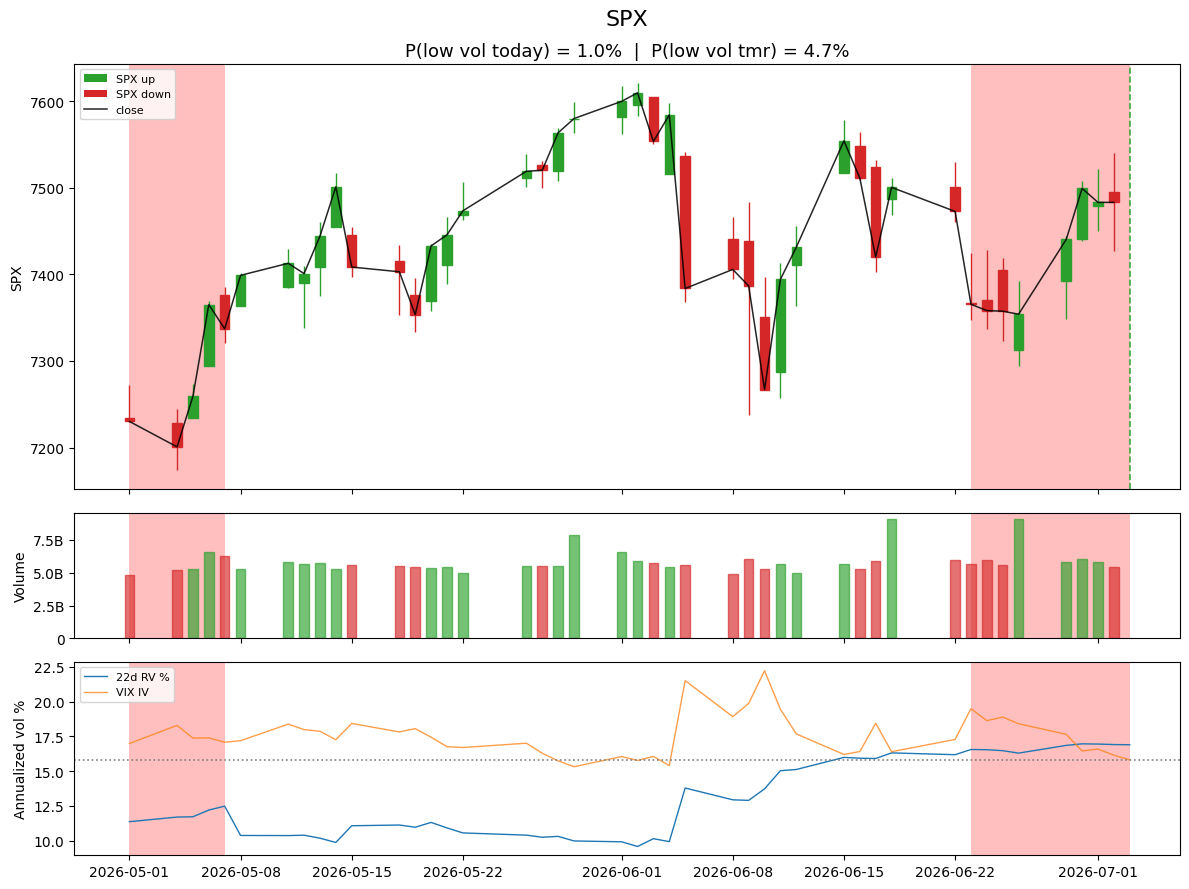


SPX implied vs realized move (1σ)
Spot = 7,478 | IV = 15.8% | 1d hist: avg |move| last 22d
Horizon | Implied   | Historical | Spot ± implied
--------+-----------+------------+---------------
1d      | 74(1.0%)  | 58(0.8%)   | 7,403 | 7,552 
15d     | 288(3.9%) | 246(3.3%)  | 7,189 | 7,766 
22d     | 349(4.7%) | 373(5.0%)  | 7,128 | 7,827 
30d     | 408(5.5%) | 380(5.1%)  | 7,070 | 7,886 


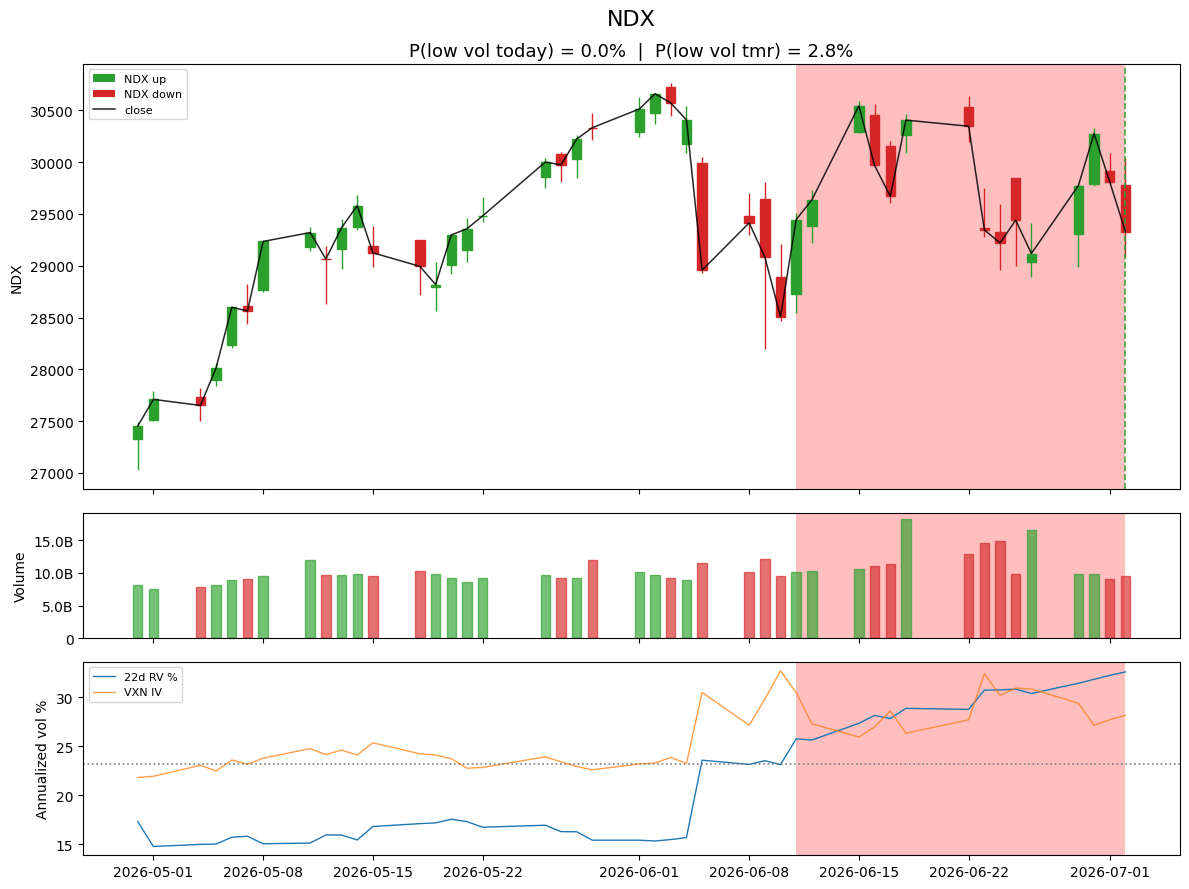


NDX implied vs realized move (1σ)
Spot = 29,311 | IV = 28.1% | 1d hist: avg |move| last 22d
Horizon | Implied     | Historical   | Spot ± implied 
--------+-------------+--------------+----------------
1d      | 519(1.8%)   | 481(1.6%)    | 28,791 | 29,830
15d     | 2,012(6.9%) | 2,277(7.8%)  | 27,299 | 31,322
22d     | 2,436(8.3%) | 2,820(9.6%)  | 26,875 | 31,747
30d     | 2,845(9.7%) | 2,923(10.0%) | 26,466 | 32,156


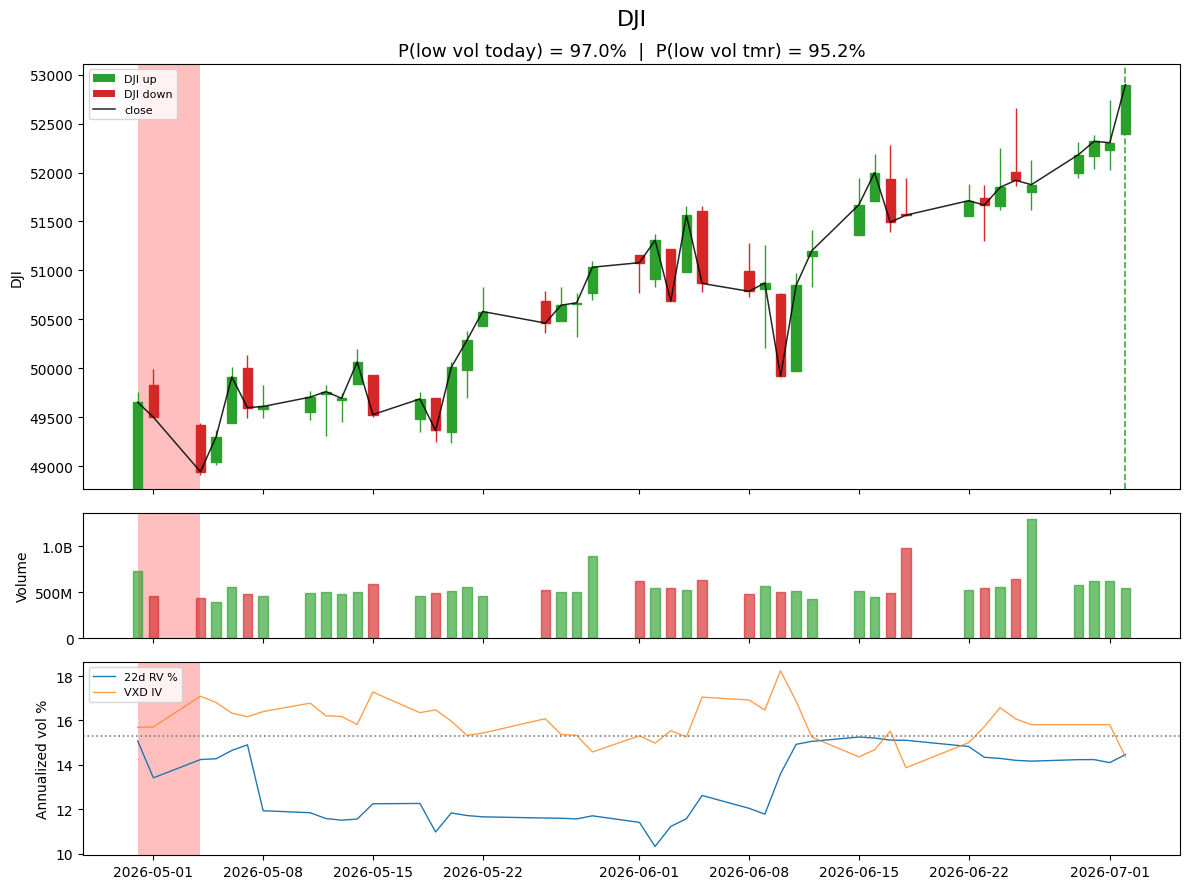


DJI implied vs realized move (1σ)
Spot = 52,865 | IV = 14.4% | 1d hist: avg |move| last 22d
Horizon | Implied     | Historical  | Spot ± implied 
--------+-------------+-------------+----------------
1d      | 478(0.9%)   | 362(0.7%)   | 52,386 | 53,343
15d     | 1,852(3.5%) | 1,306(2.5%) | 51,013 | 54,717
22d     | 2,243(4.2%) | 2,259(4.3%) | 50,622 | 55,108
30d     | 2,619(5.0%) | 2,371(4.5%) | 50,245 | 55,484


In [2]:
spx_model.display(display_period=44)
nsq_model.display(display_period=44)
dji_model.display(display_period=44)

## VOl Surface

In [3]:
# 1. Setup + fetch data
import sys, warnings
from pathlib import Path

_nb = globals().get("__vsc_ipynb_file__")
ROOT = None
for start in ([Path(_nb)] if _nb else []) + [Path.cwd()]:
    p = start.resolve()
    if p.suffix == ".ipynb": p = p.parent
    for candidate in (p, *p.parents):
        if (candidate / "vol_surface.py").is_file():
            ROOT = candidate; break
    if ROOT: break
if not ROOT: raise FileNotFoundError("Open Signal_Monitor in Cursor.")
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
import plotly.graph_objects as go
warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update(mpl.rcParamsDefault)

from vol_surface import VolSurfaceConfig, VolSurfaceStudy, latest_business_session
from surface_sentiment import SurfaceDeltaPCA, SurfacePCAConfig
from data_fetcher import RateLimiter, SafeFetchSession

# Define the target underlying index ticker: "US..SPX", "US..IXIC" (Nasdaq), or "US..DJI" (Dow Jones)
UNDERLYING_TICKER = "US..SPX"

cfg = VolSurfaceConfig(underlying=UNDERLYING_TICKER, max_dte=60, lookback_days=15)

# If other index tickers are targeted and local cache folder doesn't exist yet, 
# load_history using use_demo_if_empty=True will automatically load full simulation option matrices on the fly
try:
    import futu as ft
    limiter = RateLimiter(600)
    session = SafeFetchSession(limiter, cfg)
    ctx = ft.OpenQuoteContext(host=cfg.host, port=cfg.port)
    df = session.fetch_and_cache(ctx, max_retries=3)
    ctx.close()
    print(f"Live: {len(df)} contracts")
except Exception as e:
    print(f"Live failed: {e}, using demo/synthetic curves for {UNDERLYING_TICKER}")
    df = None

study = VolSurfaceStudy(cfg)
study.load_history(use_demo_if_empty=True) # Enabled demo simulation fallback for NDX/DJI
dates = sorted(study.surfaces.keys())
print(f"Loaded {len(dates)} sessions for {UNDERLYING_TICKER}")
print(dates[0].strftime("%Y-%m-%d"), "->", dates[-1].strftime("%Y-%m-%d"))

2026-07-04 17:31:09,577 | 21820 | 8376 | [open_context_base.py:411] _init_connect_sync: New connect ready: conn=7479104507275881136(1) context=<futu.quote.open_quote_context.OpenQuoteContext object at 0x000002235FD1D8B0>
Live: 7438 contracts
2026-07-04 17:31:47,632 | 21820 | 1724 | [open_context_base.py:521] on_disconnect: Disconnected: conn=0(1) reason=CallClose
Loaded 6 sessions for US..SPX
2026-06-22 -> 2026-07-02


2026-07-04 17:32:06,901 | 21820 | 1724 | [open_context_base.py:521] on_disconnect: Disconnected: conn=0(2) reason=CallClose


In [4]:
# 2. Run analysis + PCA

result = study.analyze()
today_f = result["today"]

pca = SurfaceDeltaPCA(SurfacePCAConfig(n_components=4, baseline_window=21))
pca_result = pca.fit(surfaces=study.surfaces)
evr = pca_result["explained_variance_ratio"]

hist_scores = pca_result["score_history"]
score_dates = pca_result["score_dates"]
composite = -(hist_scores[:, 0] / np.nanstd(hist_scores[:, 0])
              + hist_scores[:, 1] / np.nanstd(hist_scores[:, 1]))

print(f"PCA: PC1={evr[0]:.1%} PC2={evr[1]:.1%} PC3={evr[2]:.1%}")
today_scores = hist_scores[-1]
sentiment = pca.sentiment_from_scores(today_scores, hist_scores)
print(f"Today: z_PC1={today_scores[0]:+.2f} z_PC2={today_scores[1]:+.2f}")

2026-07-04 17:32:03,322 | 21820 | 8376 | [open_context_base.py:411] _init_connect_sync: New connect ready: conn=7479104732695989198(2) context=<futu.quote.open_quote_context.OpenQuoteContext object at 0x000002236853CAA0>


Not enough valid rolling delta-surfaces (0) to fit PCA components (4) or StandardScale safely. Falling back to 'prev' (day-over-day change).


PCA: PC1=60.4% PC2=38.9% PC3=0.6%
Today: z_PC1=+8.13 z_PC2=-13.64


In [5]:
# 3. Bloomberg-style 3D vol surface with IV/local vol toggle (using Moneyness K/S)

# Encapsulating the Plotly 3D visual rendering
fig = study.plot_bloomberg_3d_surface()
fig.show()

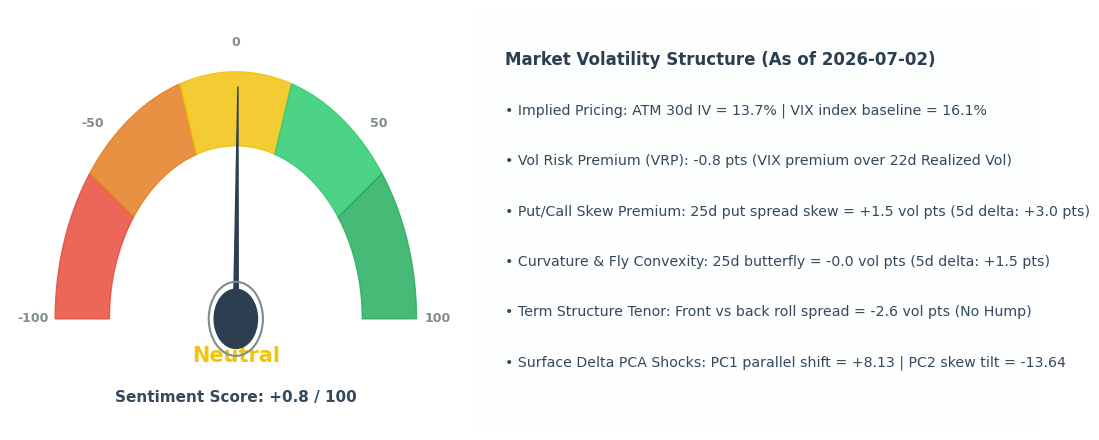

In [6]:
# 4. Compass Gauge Speedometer (Bull / Bear) & Sentiment Summary Bulletpoints

# Direct call to the encapsulated dual-panel speedometer plot
study.plot_sentiment_gauge(result=result, today_scores=today_scores, sentiment=sentiment)